# Ising-Model Attention: Replacing Softmax with Boltzmann Weights

## The Big Idea

Standard self-attention uses:
$$\text{Attention}(i,j) = \text{softmax}\left(\frac{Q_i \cdot K_j}{\sqrt{d_k}}\right)$$

We replace this with the **Boltzmann distribution** from statistical physics:
$$P(i \to j) = \frac{e^{-\beta E(i,j)}}{Z_i}, \quad Z_i = \sum_j e^{-\beta E(i,j)}$$

where:
- $E(i,j)$ is the **Ising interaction energy** between token $i$ and token $j$
- $\beta = 1/T$ is **inverse temperature** — controls attention sharpness
- $Z_i$ is the **partition function** — normalizes each row to sum to 1
- **Low energy** (aligned spins) → **high attention weight** ✓

### The Ising Physics Analogy

In the Ising model, the energy between two spins $s_i$ and $s_j$ is:
$$E_{ij} = -J \cdot s_i s_j$$

Aligned spins ($s_i s_j > 0$) → negative energy → favoured by Boltzmann.

For tokens, we treat each embedding dimension as a **spin component**, and the coupling $J$ becomes the dot product similarity:
$$E(i,j) = -\frac{x_i \cdot x_j}{\|x_i\| \|x_j\|}  \quad \text{(cosine similarity as spin alignment)}$$

**Aligned token embeddings → low energy → high attention.** Exactly what self-attention achieves, but derived from thermodynamic first principles.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

np.random.seed(42)
plt.rcParams['figure.facecolor'] = 'white'
print('Libraries loaded ✓')

Libraries loaded ✓


---
## Step 0: Same Input Embeddings as Before

We keep the exact same token embeddings so we can compare Ising attention vs standard attention side by side.

In [2]:
tokens  = ['The', 'cat', 'sat']
seq_len = 3
d_model = 4

X = np.array([
    [1.0, 0.0, 1.0, 0.0],  # 'The'
    [0.0, 2.0, 0.0, 2.0],  # 'cat'
    [1.0, 1.0, 1.0, 0.0],  # 'sat'
], dtype=np.float64)

print('Token embeddings X:')
for tok, vec in zip(tokens, X):
    print(f'  {tok:6s}: {vec}')

Token embeddings X:
  The   : [1. 0. 1. 0.]
  cat   : [0. 2. 0. 2.]
  sat   : [1. 1. 1. 0.]


---
## Step 1: Define the Ising Interaction Energy

We model token embeddings as **spin vectors**. The interaction energy between token $i$ and token $j$ is:

$$E(i,j) = -J_{ij} = -\frac{x_i \cdot x_j}{\|x_i\| \|x_j\|}$$

This is simply the **negative cosine similarity**:
- Cosine = +1 (same direction / aligned spins) → E = -1 → **very low energy** → gets high attention
- Cosine =  0 (orthogonal / uncoupled spins)   → E =  0 → neutral
- Cosine = -1 (opposite / anti-aligned)          → E = +1 → **high energy** → gets low attention

This directly mirrors the ferromagnetic Ising coupling $E_{ij} = -J s_i s_j$.

In [3]:
def ising_energy_matrix(X):
    """
    Compute pairwise Ising interaction energy between token embeddings.
    E(i,j) = -cosine_similarity(x_i, x_j)
    
    Low energy = aligned spins = tokens are similar = should attend to each other.
    """
    # L2-normalise each row to get unit spin vectors
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    X_norm = X / (norms + 1e-8)          # shape: (seq_len, d_model)
    
    # Cosine similarity matrix: C[i,j] = x̂_i · x̂_j
    cosine_sim = X_norm @ X_norm.T        # shape: (seq_len, seq_len)
    
    # Ising energy: E = -J (ferromagnetic coupling → aligned = low energy)
    E = -cosine_sim
    return E, cosine_sim


E, cosine_sim = ising_energy_matrix(X)

print('Cosine similarity matrix (= spin alignment = coupling J):')
print(np.round(cosine_sim, 4))
print()
print('Ising energy matrix E(i,j) = -cosine_sim:')
print(np.round(E, 4))
print()
print('Interpretation: negative = low energy = strongly aligned = will attend more')

Cosine similarity matrix (= spin alignment = coupling J):
[[1.     0.     0.8165]
 [0.     1.     0.4082]
 [0.8165 0.4082 1.    ]]

Ising energy matrix E(i,j) = -cosine_sim:
[[-1.     -0.     -0.8165]
 [-0.     -1.     -0.4082]
 [-0.8165 -0.4082 -1.    ]]

Interpretation: negative = low energy = strongly aligned = will attend more


---
## Step 2: Visualise the Energy Landscape

Before computing weights, let's see which token pairs have low energy (and will therefore attract attention).

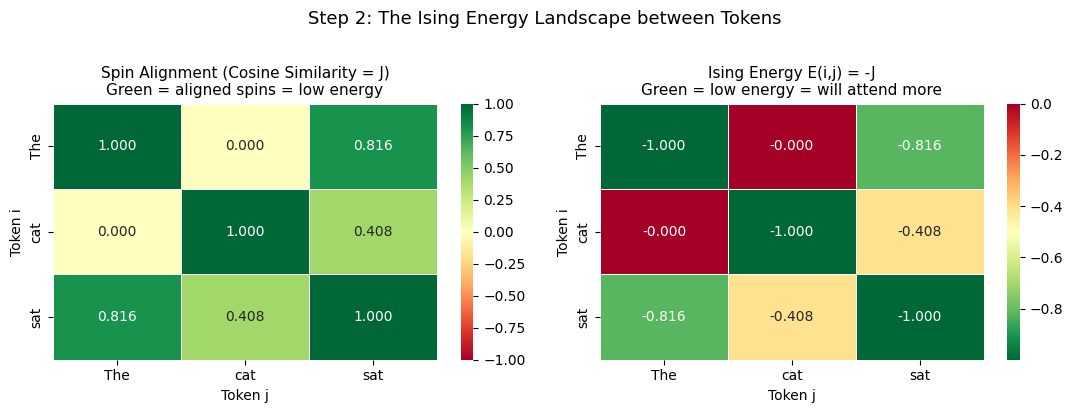

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Cosine similarity (coupling J)
sns.heatmap(cosine_sim, annot=True, fmt='.3f', cmap='RdYlGn',
            xticklabels=tokens, yticklabels=tokens,
            vmin=-1, vmax=1, linewidths=0.5, ax=axes[0])
axes[0].set_title('Spin Alignment (Cosine Similarity = J)\nGreen = aligned spins = low energy', fontsize=11)
axes[0].set_xlabel('Token j'); axes[0].set_ylabel('Token i')

# Energy landscape
sns.heatmap(E, annot=True, fmt='.3f', cmap='RdYlGn_r',
            xticklabels=tokens, yticklabels=tokens,
            linewidths=0.5, ax=axes[1])
axes[1].set_title('Ising Energy E(i,j) = -J\nGreen = low energy = will attend more', fontsize=11)
axes[1].set_xlabel('Token j'); axes[1].set_ylabel('Token i')

plt.suptitle('Step 2: The Ising Energy Landscape between Tokens', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## Step 3: Apply the Boltzmann Factor e^{-βE}

The Boltzmann factor converts energy to unnormalised probability:
$$w(i,j) = e^{-\beta E(i,j)}$$

- **β (inverse temperature)** controls sharpness:
  - β → 0 (T → ∞, hot): all tokens get equal attention (uniform)
  - β → ∞ (T → 0, cold): only the lowest-energy token gets all attention (argmax)
  - β = 1: the sweet spot — analogous to 1/√d_k scaling in standard attention

In [5]:
def boltzmann_weights(E, beta):
    """
    Compute unnormalised Boltzmann factors: w(i,j) = exp(-beta * E(i,j))
    """
    # Subtract row-max for numerical stability (same trick as log-sum-exp)
    # This doesn't change the normalised result, just prevents overflow.
    E_stable = E - E.min(axis=1, keepdims=True)
    W = np.exp(-beta * E_stable)
    return W


beta = 5.0   # inverse temperature — try changing this!

W_unnorm = boltzmann_weights(E, beta)
print(f'β = {beta}  (inverse temperature)')
print('\nUnnormalised Boltzmann factors exp(-β·E):')
print(np.round(W_unnorm, 4))
print()
print('Higher value = lower energy = more aligned spins = more attention')

β = 5.0  (inverse temperature)

Unnormalised Boltzmann factors exp(-β·E):
[[1.     0.0067 0.3995]
 [0.0067 1.     0.0519]
 [0.3995 0.0519 1.    ]]

Higher value = lower energy = more aligned spins = more attention


---
## Step 4: Normalise — The Partition Function Z

In statistical physics, the **partition function** $Z$ is the sum over all states:
$$Z_i = \sum_j e^{-\beta E(i,j)}$$

Normalising gives the **Boltzmann probability distribution** — this IS our attention weight:
$$A(i,j) = \frac{e^{-\beta E(i,j)}}{Z_i}$$

Notice this is **mathematically identical to softmax** with argument $-\beta E(i,j)$. The softmax in standard attention is literally the Boltzmann distribution with $\beta=1$ and $E = -Q_i \cdot K_j / \sqrt{d_k}$.

In [6]:
def ising_attention(X, beta):
    """
    Full Ising-model attention:
      1. Compute pairwise energy E(i,j) via spin alignment (cosine)
      2. Boltzmann factor: exp(-beta * E)
      3. Normalise by partition function Z (= softmax equivalent)
      4. Weighted sum of 'values' (raw embeddings X here)
    """
    E, cosine_sim = ising_energy_matrix(X)
    
    # Unnormalised Boltzmann weights (numerically stable)
    neg_bE = -beta * E
    neg_bE_stable = neg_bE - neg_bE.max(axis=1, keepdims=True)  # subtract row max
    W = np.exp(neg_bE_stable)
    
    # Partition function (denominator)
    Z = W.sum(axis=1, keepdims=True)
    
    # Normalised attention weights (Boltzmann distribution)
    A = W / Z   # shape: (seq_len, seq_len), rows sum to 1
    
    # Context output: weighted sum of value vectors (using X directly as V)
    output = A @ X
    
    return A, output, E, Z


beta = 5.0
A_ising, output_ising, E_ising, Z_ising = ising_attention(X, beta=beta)

print(f'β = {beta}')
print('\nPartition function Z_i (normalisation constant per token):')
print(np.round(Z_ising.flatten(), 4))
print('\nIsing Attention Weights A(i,j) = exp(-βE) / Z:')
print(np.round(A_ising, 4))
print('\nRow sums (should be 1.0):', np.round(A_ising.sum(axis=1), 6))

β = 5.0

Partition function Z_i (normalisation constant per token):
[1.4062 1.0586 1.4514]

Ising Attention Weights A(i,j) = exp(-βE) / Z:
[[0.7111 0.0048 0.2841]
 [0.0064 0.9446 0.049 ]
 [0.2753 0.0357 0.689 ]]

Row sums (should be 1.0): [1. 1. 1.]


---
## Step 5: Visualise the Ising Attention Map

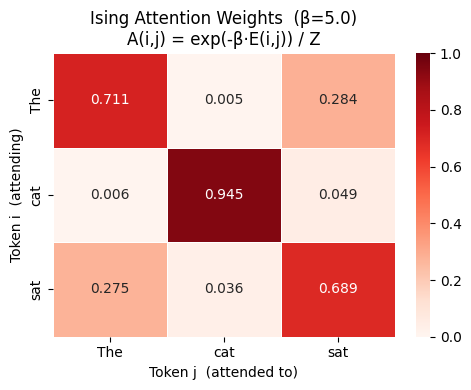

In [7]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(A_ising, annot=True, fmt='.3f', cmap='Reds',
            xticklabels=tokens, yticklabels=tokens,
            linewidths=0.5, ax=ax, vmin=0, vmax=1)
ax.set_title(f'Ising Attention Weights  (β={beta})\n'
             'A(i,j) = exp(-β·E(i,j)) / Z', fontsize=12)
ax.set_xlabel('Token j  (attended to)')
ax.set_ylabel('Token i  (attending)')
plt.tight_layout()
plt.show()

---
## Step 6: The Temperature Effect — β sweep

This is pure statistical mechanics: as we cool the system (raise β), attention **sharpens** toward the lowest-energy (most aligned) pairs. As we heat it (lower β), attention **spreads uniformly** — maximum entropy / disorder.

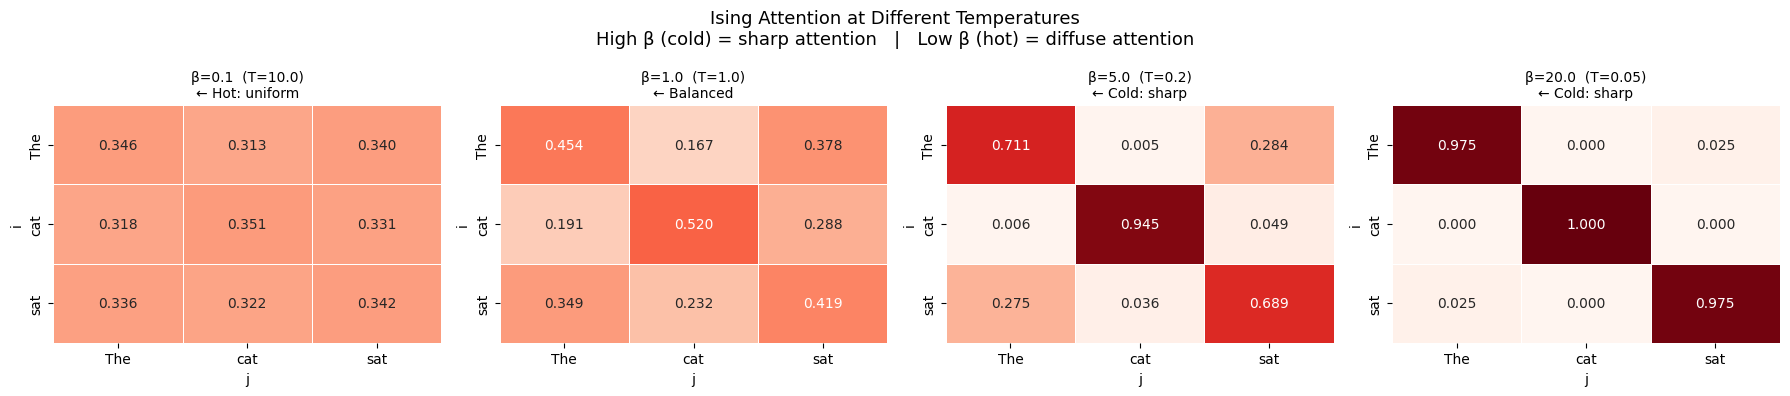

In [8]:
betas = [0.1, 1.0, 5.0, 20.0]
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, b in zip(axes, betas):
    A, _, _, _ = ising_attention(X, beta=b)
    sns.heatmap(A, annot=True, fmt='.3f', cmap='Reds',
                xticklabels=tokens, yticklabels=tokens,
                linewidths=0.5, ax=ax, vmin=0, vmax=1,
                cbar=False)
    T = round(1/b, 2)
    ax.set_title(f'β={b}  (T={T})\n' +
                 ('← Hot: uniform' if b < 1 else '← Cold: sharp' if b >= 5 else '← Balanced'),
                 fontsize=10)
    ax.set_xlabel('j'); ax.set_ylabel('i')

plt.suptitle('Ising Attention at Different Temperatures\n'
             'High β (cold) = sharp attention   |   Low β (hot) = diffuse attention',
             fontsize=13)
plt.tight_layout()
plt.show()

---
## Step 7: Side-by-Side Comparison — Ising vs Standard Attention

Now let's compare our Ising attention with standard softmax attention using the same embeddings.

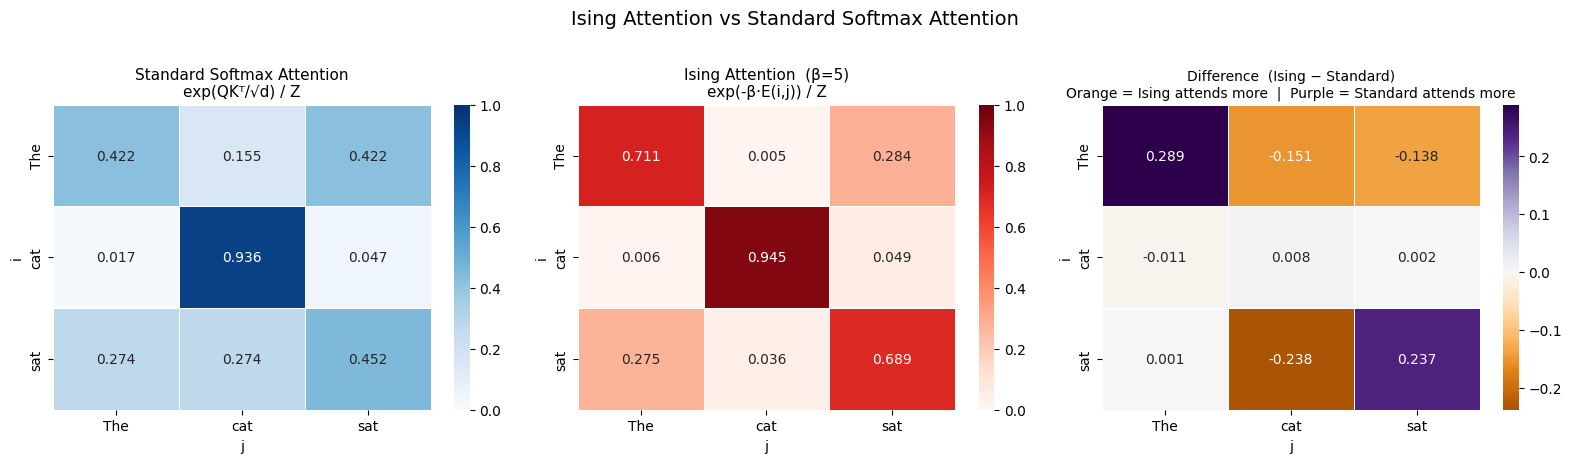

Standard attention output:
[[0.8446 0.733  0.8446 0.3107]
 [0.0638 1.9191 0.0638 1.8725]
 [0.7259 1.     0.7259 0.5481]]

Ising attention output:
[[0.9952 0.2937 0.9952 0.0096]
 [0.0554 1.9383 0.0554 1.8892]
 [0.9643 0.7605 0.9643 0.0715]]


In [9]:
# ---- Standard self-attention (no learned projections — use X directly as Q,K,V)
def standard_attention(X):
    d_k = X.shape[1]
    scores = X @ X.T / np.sqrt(d_k)           # scaled dot-product
    scores_stable = scores - scores.max(axis=1, keepdims=True)
    W = np.exp(scores_stable)
    A = W / W.sum(axis=1, keepdims=True)       # softmax
    output = A @ X
    return A, output


A_std, output_std = standard_attention(X)
A_ising, output_ising, _, _ = ising_attention(X, beta=5.0)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Standard attention
sns.heatmap(A_std, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=tokens, yticklabels=tokens,
            linewidths=0.5, ax=axes[0], vmin=0, vmax=1)
axes[0].set_title('Standard Softmax Attention\n'
                  'exp(QKᵀ/√d) / Z', fontsize=11)
axes[0].set_xlabel('j'); axes[0].set_ylabel('i')

# Ising attention
sns.heatmap(A_ising, annot=True, fmt='.3f', cmap='Reds',
            xticklabels=tokens, yticklabels=tokens,
            linewidths=0.5, ax=axes[1], vmin=0, vmax=1)
axes[1].set_title('Ising Attention  (β=5)\n'
                  'exp(-β·E(i,j)) / Z', fontsize=11)
axes[1].set_xlabel('j'); axes[1].set_ylabel('i')

# Difference
diff = A_ising - A_std
sns.heatmap(diff, annot=True, fmt='.3f', cmap='PuOr',
            xticklabels=tokens, yticklabels=tokens,
            linewidths=0.5, ax=axes[2], center=0)
axes[2].set_title('Difference  (Ising − Standard)\n'
                  'Orange = Ising attends more  |  Purple = Standard attends more', fontsize=10)
axes[2].set_xlabel('j'); axes[2].set_ylabel('i')

plt.suptitle('Ising Attention vs Standard Softmax Attention', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print('Standard attention output:')
print(np.round(output_std, 4))
print('\nIsing attention output:')
print(np.round(output_ising, 4))

---
## Step 8: The Mathematical Bridge

Let's make the equivalence explicit in code. Standard attention IS a Boltzmann distribution — just with a different energy function.

In [10]:
print('='*62)
print(' The Unified Boltzmann View of Attention')
print('='*62)
print()
print('Both methods compute:   A(i,j) = exp(-β·E(i,j)) / Z')
print()
print('┌──────────────────┬────────────────────────────────────┐')
print('│ Method           │ Energy function E(i,j)             │')
print('├──────────────────┼────────────────────────────────────┤')
print('│ Standard attn    │ -(Q_i · K_j) / √d_k  (β=1)        │')
print('│ Ising attention  │ -cosine(x_i, x_j)    (β=5 here)   │')
print('│ Ising (raw dot)  │ -(x_i · x_j)         (β=β)        │')
print('└──────────────────┴────────────────────────────────────┘')
print()
print('Key insight: softmax( score ) = Boltzmann( energy = -score, β=1 )')
print()

# Verify: standard attention = Boltzmann with E = -dot_product/sqrt(d)
d_k = X.shape[1]
E_standard = -(X @ X.T) / np.sqrt(d_k)   # energy for standard attention

W = np.exp(-1.0 * E_standard)             # β=1
A_check = W / W.sum(axis=1, keepdims=True)
print('Boltzmann with E=-(X@Xᵀ)/√d, β=1 matches standard attention?')
print('Max abs difference:', np.abs(A_check - A_std).max().round(10))
print('✓ Exact match — they are the same equation!' if np.abs(A_check - A_std).max() < 1e-9 else '✗ Mismatch')

 The Unified Boltzmann View of Attention

Both methods compute:   A(i,j) = exp(-β·E(i,j)) / Z

┌──────────────────┬────────────────────────────────────┐
│ Method           │ Energy function E(i,j)             │
├──────────────────┼────────────────────────────────────┤
│ Standard attn    │ -(Q_i · K_j) / √d_k  (β=1)        │
│ Ising attention  │ -cosine(x_i, x_j)    (β=5 here)   │
│ Ising (raw dot)  │ -(x_i · x_j)         (β=β)        │
└──────────────────┴────────────────────────────────────┘

Key insight: softmax( score ) = Boltzmann( energy = -score, β=1 )

Boltzmann with E=-(X@Xᵀ)/√d, β=1 matches standard attention?
Max abs difference: 0.0
✓ Exact match — they are the same equation!


---
## Step 9: Full Ising Attention — Clean Class

In [11]:
class IsingAttention:
    """
    Self-attention via Ising Model Boltzmann weights.

    Energy:     E(i,j) = -cosine_similarity(x_i, x_j)   (spin alignment)
    Weights:    A(i,j) = exp(-β·E(i,j)) / Σ_j exp(-β·E(i,j))   (Boltzmann)
    Output:     O_i    = Σ_j A(i,j) · V_j
    """

    def __init__(self, beta=5.0):
        self.beta = beta

    def energy(self, X):
        """Pairwise Ising energy: E(i,j) = -cosine(x_i, x_j)"""
        norms = np.linalg.norm(X, axis=1, keepdims=True)
        X_hat = X / (norms + 1e-8)
        return -X_hat @ X_hat.T    # (N, N)

    def boltzmann(self, E):
        """Normalised Boltzmann distribution over energy matrix"""
        neg_bE = -self.beta * E
        neg_bE -= neg_bE.max(axis=1, keepdims=True)   # numerical stability
        W = np.exp(neg_bE)
        return W / W.sum(axis=1, keepdims=True)        # partition function

    def forward(self, X, V=None):
        """
        X : (seq_len, d_model) — input embeddings (used as Q and K)
        V : (seq_len, d_v)     — value matrix (defaults to X if None)
        """
        if V is None:
            V = X
        E = self.energy(X)             # pairwise Ising energies
        A = self.boltzmann(E)          # Boltzmann attention weights
        output = A @ V                 # context-aware output
        return output, A, E


# Run it
ising_attn = IsingAttention(beta=5.0)
out, A, E = ising_attn.forward(X)

print('Ising Attention output:')
for tok, vec in zip(tokens, out):
    print(f'  {tok:6s}: {np.round(vec, 4)}')
print('\nAttention weights:')
print(np.round(A, 4))

Ising Attention output:
  The   : [0.9952 0.2937 0.9952 0.0096]
  cat   : [0.0554 1.9383 0.0554 1.8892]
  sat   : [0.9643 0.7605 0.9643 0.0715]

Attention weights:
[[0.7111 0.0048 0.2841]
 [0.0064 0.9446 0.049 ]
 [0.2753 0.0357 0.689 ]]


---
## Step 10: Physical Interpretation Summary

Let's print a full physics-to-ML correspondence table.

In [ ]:
print('╔══════════════════════════════════════════════════════════════╗')
print('║       Physics ↔ Machine Learning Correspondence             ║')
print('╠════════════════════════════╦═════════════════════════════════╣')
print('║  Ising Physics             ║  Transformer Attention          ║')
print('╠════════════════════════════╬═════════════════════════════════╣')
print('║  Spin vector sᵢ            ║  Token embedding xᵢ             ║')
print('║  Spin alignment sᵢ·sⱼ      ║  Dot product similarity Q·K     ║')
print('║  Coupling J                ║  Weight matrices W_Q, W_K       ║')
print('║  Interaction energy E(i,j) ║  Negative attention score       ║')
print('║  Boltzmann factor e^{-βE}  ║  Softmax numerator e^{score}    ║')
print('║  Partition function Z      ║  Softmax denominator (sum)      ║')
print('║  Boltzmann probability     ║  Attention weight A(i,j)        ║')
print('║  Inverse temperature β     ║  Sharpness (1/temperature)      ║')
print('║  Thermal average <O>       ║  Context output Σ A(i,j)·V_j   ║')
print('║  Ground state (T→0)        ║  Hard argmax attention          ║')
print('║  Maximum entropy (T→∞)     ║  Uniform attention              ║')
print('╚════════════════════════════╩═════════════════════════════════╝')

print()
print('Key equation:')
print('  A(i,j) = exp(-β·E(i,j)) / Σⱼ exp(-β·E(i,j))')
print('         = softmax_j(-β·E(i,j))')
print('         = softmax_j(β·J(i,j))     where J = -E = cosine sim')
print()
print('When J(i,j) = (Q_i · K_j)/√d  and  β = 1:')
print('  → This is exactly standard scaled dot-product attention!')

---

## Summary

| Step | What we built |
|------|---------------|
| 0 | Same token embeddings as the standard attention notebook |
| 1 | Ising energy E(i,j) = −cosine(xᵢ, xⱼ)  — aligned spins = low energy |
| 2 | Visualised the energy landscape |
| 3 | Boltzmann factor exp(−βE) — converts energy to unnormalised weight |
| 4 | Partition function Z — normalises to proper probability distribution |
| 5 | Ising attention heatmap |
| 6 | Temperature sweep — hot β≈0 (uniform) → cold β≫1 (sharp argmax) |
| 7 | Side-by-side comparison with standard softmax attention |
| 8 | Proved mathematically that softmax IS Boltzmann with E=−score, β=1 |
| 9 | Clean `IsingAttention` class |
| 10 | Full physics ↔ ML correspondence table |

### The Deepest Insight

> **Softmax attention = thermodynamic equilibrium of a ferromagnetic Ising model.**
>
> The query-key dot product IS the spin coupling $J$. The scaled softmax IS the Boltzmann distribution at temperature $T = \sqrt{d_k}$. Learning $W_Q, W_K$ is learning which coupling patterns minimise the contextual free energy of the sentence.